# Models vs GPT

In [1]:
from src.dataset import Dataset, Tag, Document
import json

In [2]:
with open(f"data/tagged/gt_filtered_v2.json", "r") as file:
    gt = Dataset.from_dict(json.load(file))
with open(f"data/gpt_o4.json", "r") as file:
    gpt = Dataset.from_dict(json.load(file))
with open(f"data/gpt_5.json", "r") as file:
    gpt5 = Dataset.from_dict(json.load(file))
with open(f"data/spacy_llm_gpt_4o.json", "r") as file:
    spacy_llm_gpt_4o = Dataset.from_dict(json.load(file))
with open(f"data/gpt_o4_markdown.json", "r") as file:
    gpt_markdown = Dataset.from_dict(json.load(file))
with open(f"data/gpt_o4_mini.json", "r") as file:
    gpt_mini = Dataset.from_dict(json.load(file))
with open(f"data/gpt_o4_mini_markdown.json", "r") as file:
    gpt_mini_markdown = Dataset.from_dict(json.load(file))
with open(f"data/gpt_5_markdown.json", "r") as file:
    gpt5_markdown = Dataset.from_dict(json.load(file))
with open(f"data/deepseek_json.json", "r") as file:
    deepseek_json = Dataset.from_dict(json.load(file))
with open(f"data/deepseek_md.json", "r") as file:
    deepseek_md = Dataset.from_dict(json.load(file))
with open(f"data/deepseek_chat_json.json", "r") as file:
    deepseek_chat_json = Dataset.from_dict(json.load(file))
with open(f"data/deepseek_chat_md.json", "r") as file:
    deepseek_chat_md = Dataset.from_dict(json.load(file))
with open(f"data/claude_sonnet_json.json", "r") as file:
    claude_sonnet_json = Dataset.from_dict(json.load(file))
with open(f"data/claude_sonnet_md.json", "r") as file:
    claude_sonnet_md = Dataset.from_dict(json.load(file))
with open(f"data/claude_haiku_json.json", "r") as file:
    claude_haiku_json = Dataset.from_dict(json.load(file))
with open(f"data/claude_haiku_md.json", "r") as file:
    claude_haiku_md = Dataset.from_dict(json.load(file))
with open(f"data/spacy_md.json", "r") as file:
    spacy_md = Dataset.from_dict(json.load(file))
with open(f"data/spacy_trf.json", "r") as file:
    spacy_trf = Dataset.from_dict(json.load(file))
with open(f"data/xml_roberta_tuned.json", "r") as file:
    roberta_tuned = Dataset.from_dict(json.load(file))
with open(f"data/xlm-roberta.json", "r") as file:
    roberta = Dataset.from_dict(json.load(file))
with open(f"data/spacy_trf_tuned_v2.json", "r") as file:
    spacy_trf_tuned = Dataset.from_dict(json.load(file))

In [3]:
assert set(gt.keys()) == set(gpt.keys())
assert set(gt.keys()) == set(spacy_md.keys())
assert set(gt.keys()) == set(gpt_markdown.keys())
assert set(gt.keys()) == set(spacy_trf.keys())
assert set(gt.keys()) == set(roberta.keys())
assert set(gt.keys()) == set(deepseek_json.keys())
assert set(gt.keys()) == set(roberta_tuned.keys())
assert set(gt.keys()) == set(spacy_trf_tuned.keys())

In [4]:
models = {"gpt5": gpt5, "gpt5_markdown": gpt5_markdown, "gpt": gpt, "gpt_markdown": gpt_markdown, 
          "gpt_mini": gpt_mini, "gpt_mini_markdown": gpt_mini_markdown,
          "spacy_llm_4o": spacy_llm_gpt_4o,
          "deepseek_json": deepseek_json, "deepseek_markdown": deepseek_md, 
          "deepseek_chat_json": deepseek_chat_json, "deepseek_chat_md": deepseek_chat_md,
          "claude_sonnet_json": claude_sonnet_json, "claude_sonnet_md": claude_sonnet_md,
          "claude_haiku_json": claude_haiku_json, "claude_haiku_md": claude_haiku_md,
          "spacy_md": spacy_md, 
          "spacy_trf": spacy_trf, "roberta": roberta, "roberta_tuned": roberta_tuned, "spacy_trf_tuned": spacy_trf_tuned}

In [5]:
mapping = {
    "gpt5": "GPT 5 JSON",
    "gpt5_markdown": "GPT 5 Markdown",
    "gpt": "GPT 4o JSON",
    "gpt_markdown": "GPT 4o Markdown",
    "gpt_mini": "GPT mini JSON",
    "gpt_mini_markdown": "GPT mini Markdown",
    "spacy_llm_4o": "Spacy LLM 4o",
    "deepseek_json": "Deepseek (reasoning) JSON",
    "deepseek_markdown": "Deepseek (reasoning) Markdown",
    "deepseek_chat_json": "Deepseek (chat) JSON",
    "deepseek_chat_md": "Deepseek (chat) Markdown",
    "claude_sonnet_json": "Claude Sonnet JSON",
    "claude_sonnet_md": "Claude Sonnet Markdown",
    "claude_haiku_json": "Clade Haiku JSON",
    "claude_haiku_md": "Claude Haiku Markdown",
    "spacy_md": "Spacy MD",
    "spacy_trf": "Spacy TRF",
    "roberta": "XML-Roberta",
    "roberta_tuned": "XML-Roberta tuned",
    "spacy_trf_tuned": "Spacy TRF tuned",
}

In [6]:
from src.llm_json_tagging import coerce_tags
def weak_contains(tag, doc):
    sorted_doc = sorted(doc.tags, key=lambda x: x.start)
    for t in sorted_doc:
        if t.end < tag.start:
            continue
        if tag.start < t.end and t.start < tag.end:
            return t
    return None

def take_metrics(gt_doc, model_doc):
    false_positives = []
    true_positives = []
    incomplete = []
    false_negative = []
    partial_positive_tags = set()
    for t in gt_doc.tags:
        if not weak_contains(t, model_doc):
            false_negative.append(t)
    for t in coerce_tags(model_doc.text, model_doc.tags):
        if t in gt_doc.tags:
            true_positives.append(t)
            continue
        weak_match_tag = weak_contains(t, gt_doc)
        if weak_match_tag and ("the "+weak_match_tag.text == t.text or weak_match_tag.text == "the "+t.text):
            true_positives.append(t)
            continue
        if weak_match_tag and weak_match_tag not in partial_positive_tags:
            partial_positive_tags.add(weak_match_tag)
            incomplete.append(t)
        elif weak_match_tag:
            continue
        else:
            false_positives.append(t)
    assert len(incomplete)+len(true_positives)+len(false_negative) <= len(gt_doc.tags)
    return false_positives, true_positives, incomplete, false_negative

In [7]:
false_positive_list = {k:[] for k in models.keys()}
false_negative_list = {k:[] for k in models.keys()}
false_positives = {k:0 for k in models.keys()}
true_positives = {k:0 for k in models.keys()}
incomplete = {k:0 for k in models.keys()}
model_positives = {k:0 for k in models.keys()}
false_negative = {k:0 for k in models.keys()}
gt_tag_count = {k:0 for k in models.keys()}
for k in gt.keys():
    real_doc = gt[k]
    for m in models.keys():
        model_doc = models[m][k]
        fps, tps, inc, fn = take_metrics(real_doc, model_doc)
        if len(inc)+len(tps) > len(real_doc.tags):
            raise Exception
        false_positive_list[m]+=[(k, p) for p in fps]
        false_negative_list[m]+=[(k, p) for p in fn]
        false_positives[m]+=len(fps)
        true_positives[m]+=len(tps)
        incomplete[m]+=len(inc)
        false_negative[m]+=len(fn)
        model_positives[m] += len(model_doc.tags)
        gt_tag_count[m] += len(real_doc.tags)

In [8]:
import pandas as pd
df = pd.DataFrame([false_positives, incomplete , true_positives, model_positives, false_negative, gt_tag_count]).T
df.columns = ["False positives", "Incomplete positives", "True positives", "Total positives", "False negatives", "Real tags"]
df

,False positives,Incomplete positives,True positives,Total positives,False negatives,Real tags
gpt5,918,950,5933,8133,360,7745
gpt5_markdown,1099,1120,5991,8697,91,7745
gpt,698,269,6366,9630,1108,7745
gpt_markdown,2362,910,6250,10498,268,7745
gpt_mini,1163,742,5428,10234,1524,7745
gpt_mini_markdown,3680,948,5919,11750,644,7745
spacy_llm_4o,1374,775,6019,9729,732,7745
deepseek_json,1046,722,5877,8032,887,7745
deepseek_markdown,1170,944,6043,8668,286,7745
deepseek_chat_json,956,652,5582,8386,1363,7745


In [9]:
df_rates = df.copy()
df_rates["Agreement exact"] = (df["True positives"])/(df["Real tags"]+df["False positives"]+df["Incomplete positives"])
df_rates["Precision exact"] = (df["True positives"])/(df["True positives"]+df["Incomplete positives"]+df["False positives"])
df_rates["Recall exact"] = (df["True positives"])/(df["True positives"]+df["Incomplete positives"]+df["False negatives"])
df_rates["F1 exact"] = 2*(df_rates["Precision exact"]*df_rates["Recall exact"])/(df_rates["Precision exact"]+df_rates["Recall exact"])

df_rates["Agreement partial"] = (df["True positives"]+df["Incomplete positives"])/(df["Real tags"]+df["False positives"]+df["Incomplete positives"])
df_rates["Precision partial"] = (df["True positives"]+df["Incomplete positives"])/(df["True positives"]+df["Incomplete positives"]+df["False positives"])
df_rates["Recall partial"] = (df["True positives"]+df["Incomplete positives"])/(df["True positives"]+df["Incomplete positives"]+df["False negatives"])
df_rates["F1 partial"] = 2*(df_rates["Precision partial"]*df_rates["Recall partial"])/(df_rates["Precision partial"]+df_rates["Recall partial"])

plot_data=df_rates.rename(index=mapping)[["Precision exact", "Recall exact", "F1 exact", "Precision partial", "Recall partial", "F1 partial"]].round(2).T
plot_data

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Precision exact,0.76,0.73,0.87,0.66,0.74,0.56,0.74,0.77,0.74,0.78,0.59,0.79,0.73,0.79,0.69,0.59,0.68,0.62,0.76,0.83
Recall exact,0.82,0.83,0.82,0.84,0.71,0.79,0.80,0.79,0.83,0.73,0.81,0.76,0.79,0.69,0.76,0.52,0.70,0.27,0.44,0.85
F1 exact,0.79,0.78,0.84,0.74,0.72,0.66,0.77,0.78,0.78,0.75,0.68,0.77,0.76,0.73,0.72,0.55,0.69,0.37,0.56,0.84
Precision partial,0.88,0.87,0.90,0.75,0.84,0.65,0.83,0.86,0.86,0.87,0.70,0.88,0.84,0.89,0.79,0.87,0.92,0.90,0.90,0.93
Recall partial,0.95,0.99,0.86,0.96,0.80,0.91,0.90,0.88,0.96,0.82,0.97,0.85,0.91,0.77,0.88,0.76,0.94,0.39,0.52,0.95
F1 partial,0.92,0.92,0.88,0.84,0.82,0.76,0.87,0.87,0.91,0.84,0.81,0.87,0.88,0.82,0.83,0.81,0.93,0.54,0.66,0.94


In [10]:
plot_data.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Precision exact,0.73,0.87,0.66,0.74,0.59,0.62,0.68,0.76,0.83
Recall exact,0.83,0.82,0.84,0.80,0.52,0.27,0.70,0.44,0.85
F1 exact,0.78,0.84,0.74,0.77,0.55,0.37,0.69,0.56,0.84
Precision partial,0.87,0.90,0.75,0.83,0.87,0.90,0.92,0.90,0.93
Recall partial,0.99,0.86,0.96,0.90,0.76,0.39,0.94,0.52,0.95
F1 partial,0.92,0.88,0.84,0.87,0.81,0.54,0.93,0.66,0.94


In [11]:
plot_data.T.iloc[:-5,:]

,Precision exact,Recall exact,F1 exact,Precision partial,Recall partial,F1 partial
GPT 5 JSON,0.76,0.82,0.79,0.88,0.95,0.92
GPT 5 Markdown,0.73,0.83,0.78,0.87,0.99,0.92
GPT 4o JSON,0.87,0.82,0.84,0.90,0.86,0.88
GPT 4o Markdown,0.66,0.84,0.74,0.75,0.96,0.84
GPT mini JSON,0.74,0.71,0.72,0.84,0.80,0.82
GPT mini Markdown,0.56,0.79,0.66,0.65,0.91,0.76
Spacy LLM 4o,0.74,0.80,0.77,0.83,0.90,0.87
Deepseek (reasoning) JSON,0.77,0.79,0.78,0.86,0.88,0.87
Deepseek (reasoning) Markdown,0.74,0.83,0.78,0.86,0.96,0.91
Deepseek (chat) JSON,0.78,0.73,0.75,0.87,0.82,0.84


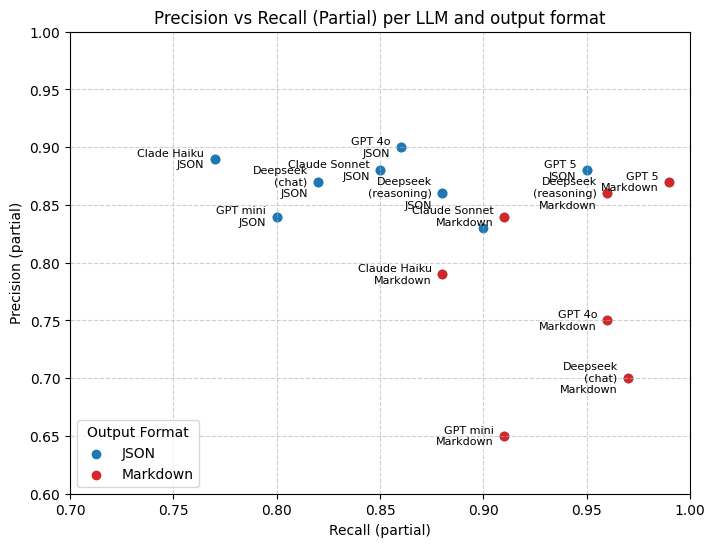

In [13]:
import matplotlib.pyplot as plt

plot_data = df_rates.rename(index=mapping)[["Precision exact", "Recall exact", "F1 exact", "Precision partial", "Recall partial", "F1 partial"]].round(2).T
plot_data =plot_data[plot_data.columns[:-5]]
# Extract partial precision and recall rows
precision_partial = plot_data.loc["Precision partial"]
recall_partial = plot_data.loc["Recall partial"]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(recall_partial, precision_partial, color='tab:blue')

# Annotate each point with its column/model name

for model in plot_data.columns:
    if "Spacy" in model:
        continue
    # Determine color based on model type
    color = "tab:blue" if "JSON" in model else "tab:red"

    # Add line break before 'JSON' or 'Markdown'
    label = (
        model.replace(" JSON", "\nJSON")
             .replace(" Markdown", "\nMarkdown")
        .replace(" (chat)", "\n(chat)")
        .replace(" (reasoning)", "\n(reasoning)")
    )

    # Plot the point
    plt.scatter(recall_partial[model], precision_partial[model], color=color)

    # Annotate label to the *left* of each point
    plt.annotate(
        label,
        (recall_partial[model] - 0.005, precision_partial[model]),
        fontsize=8,
        color='black',
        ha='right',  # align text to the right edge (so it's left of the point)
        va='center'
    )

plt.xlabel("Recall (partial)")
plt.ylabel("Precision (partial)")
plt.title("Precision vs Recall (Partial) per LLM and output format")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0.7, 1.0)
plt.ylim(0.6, 1.0)
plt.scatter([], [], color='tab:blue', label='JSON')
plt.scatter([], [], color='tab:red', label='Markdown')
plt.legend(title="Output Format", loc='lower left')
plt.savefig("plots/precision_recall_model_format.png", bbox_inches="tight")

plt.show()

### Error selection

# False negatives/positives

In [14]:
def get_tags_by_group(gt_doc, model_doc):
    false_positives = []
    true_positives = []
    incomplete = []
    false_negative = []
    partial_positive_tags = set()
    for t in gt_doc.tags:
        if not weak_contains(t, model_doc):
            false_negative.append(t)
    for t in model_doc.tags:
        if t in gt_doc.tags:
            true_positives.append(t)
            continue
        weak_match_tag = weak_contains(t, gt_doc)
        if weak_match_tag and weak_match_tag not in partial_positive_tags:
            partial_positive_tags.add(weak_match_tag)
            incomplete.append(t)
        elif weak_match_tag:
            continue
        else:
            false_positives.append(t)
    return false_positives, true_positives, incomplete, false_negative

In [15]:
fp_by_model = {m: {k: {} for k in gt.keys()} for m in models.keys()}
fn_by_model = {m: {k: {} for k in gt.keys()} for m in models.keys()}
tps_by_model = {m: {k: {} for k in gt.keys()} for m in models.keys()}
incs_by_model = {m: {k: {} for k in gt.keys()} for m in models.keys()}

for k in gt.keys():
    real_doc = gt[k]
    for m in models.keys():
        model_doc = models[m][k]
        fps, tps, inc, fn = get_tags_by_group(real_doc, model_doc)
        fp_by_model[m][k] = fps
        fn_by_model[m][k] = fn
        tps_by_model[m][k] = tps
        incs_by_model[m][k] = inc

In [16]:
geotagged = pd.read_csv("geotagged.csv")
geotagged["lead_id"] = geotagged["lead_id"].astype("str")

In [17]:
geotagged = geotagged.set_index(["lead_id", "start", "end"])["id"].fillna(-1).astype("int").to_dict()

In [18]:
from src.geocoding.geonames_search.dataframe_geonames_searcher import DataFrameGeoNamesSearcher

In [19]:
geonames_searcher = DataFrameGeoNamesSearcher("allCountries.txt")

In [20]:
geoname_country = geonames_searcher.geonames_df.set_index("geonameid")["country_code"].to_dict()

In [353]:
import os
from src.geocoding.geonames_agent import GeoNamesAgent, Settings
from src.geocoding.geonames_search.pelias_geonames_search import PeliasGeoNamesSearcher
from getpass import getpass
from src.dataset import Dataset, Tag
import json
import random
from tqdm import tqdm

In [354]:
os.environ["OPENAI_API_KEY"] = getpass()

 ········


In [355]:
searcher = PeliasGeoNamesSearcher()

In [356]:
CONTEXT_SPAN = 400

def highlight_context(text: str, tag: Tag) -> str:
    assert text[tag.start:tag.end] == tag.text
    return text[:tag.start] + "**" + text[tag.start:tag.end] + "**" + text[tag.end:]

agent = GeoNamesAgent(searcher, Settings(verbose=False, max_iterations=20, model='gpt-4o'))

In [357]:
fps_to_recompute = {}

In [21]:
import pickle
with open("fps_to_recompute.pickle", "rb") as file:
    fps_to_recompute = pickle.load(file)
len(fps_to_recompute)

9752

In [22]:
to_process = set()

for m in models.keys():
    for k in fn_by_model[m].keys():
        for t in fp_by_model[m][k]:
            if (k, t.start, t.end) in geotagged:
                if geotagged[(k, t.start, t.end)] != -1:
                    continue
            else:
                if not (k, t.start, t.end) in fps_to_recompute:
                    to_process.add((k, t))

In [23]:
len(to_process)

0

In [361]:
filtered[0]

('52022', Tag(text=Brazilian public education system, start=3260, end=3293))

In [362]:
tagged = fps_to_recompute

In [363]:
import multiprocessing as mp
from tqdm import tqdm
import pickle

filtered = [it for it in to_process if (it[0], it[1].start, it[1].end) not in fps_to_recompute]
print(len(filtered))

def _process_item(k_tag):
    k,t = k_tag
    cttx = highlight_context(gt[k].text, t)[max(t.start-CONTEXT_SPAN, 0):t.end+CONTEXT_SPAN]
    result = agent.run_agent(t.text, cttx)
    if not (isinstance(result, dict) and "selections" in result):
        return k, []
    result_list = []
    for s in result["selections"]:
        if "id" not in s:
            continue
        result_list.append(int(s["id"]))
    return (k, t.start, t.end), result_list

BATCH_SIZE = 200

for i in range(0, len(filtered), BATCH_SIZE):
    batch = filtered[i : i + BATCH_SIZE]
    with mp.Pool(processes=12) as pool:
        for k, v in tqdm(
            pool.imap_unordered(_process_item, batch),
            total=len(batch)
        ):
            fps_to_recompute[k] = v
    with open("backup_2.pickle", "wb") as file:
        pickle.dump(fps_to_recompute, file)

362


100%|███████████████████████████████████████████████████████████████████████████████████████████| 162/162 [01:32<00:00,  1.76it/s]


In [367]:
import pickle
if len(fps_to_recompute) > 0:
    with open("fps_to_recompute.pickle", "wb") as file:
        pickle.dump(fps_to_recompute, file)
len(fps_to_recompute)

9752

In [24]:
geoname_country[13192977] = "SD"

In [34]:
geoname_country[6255148]

nan

In [36]:
from tqdm import tqdm

fn_countries_by_model = {m: [] for m in models.keys()}
tp_countries_by_model = {m: [] for m in models.keys()}
fp_countries_by_model = {m: [] for m in models.keys()}

for m in tqdm(models.keys()):
    for k in fn_by_model[m].keys():
        for t in fn_by_model[m][k]:
            if (k, t.start, t.end) in geotagged and geotagged[(k, t.start, t.end)] != -1:
                fn_countries_by_model[m].append(geoname_country[geotagged[(k, t.start, t.end)]])
        for t in tps_by_model[m][k]:
            if (k, t.start, t.end) in geotagged and geotagged[(k, t.start, t.end)] != -1:
                tp_countries_by_model[m].append(geoname_country[geotagged[(k, t.start, t.end)]])
        for t in incs_by_model[m][k]:
            t = weak_contains(t, gt[k])
            assert not t is None
            if (k, t.start, t.end) in geotagged and geotagged[(k, t.start, t.end)] != -1:
                tp_countries_by_model[m].append(geoname_country[geotagged[(k, t.start, t.end)]])
        for t in fp_by_model[m][k]:
            if (k, t.start, t.end) in geotagged:
                if geotagged[(k, t.start, t.end)] == -1:
                    continue
                fp_countries_by_model[m].append(geoname_country[geotagged[(k, t.start, t.end)]])
            else:
                if (k, t.start, t.end) in fps_to_recompute:
                    for geo_id in fps_to_recompute[(k, t.start, t.end)]:
                        fp_countries_by_model[m].append(geoname_country[geo_id])
                    continue
                cttx = highlight_context(gt[k].text, t)[max(t.start-CONTEXT_SPAN, 0):t.end+CONTEXT_SPAN]
                result = agent.run_agent(t.text, cttx)
                fps_to_recompute[(k, t.start, t.end)] = []
                if not (isinstance(result, dict) and "selections" in result):
                    continue
                for s in result["selections"]:
                    if "id" not in s:
                        continue
                    fps_to_recompute[(k, t.start, t.end)].append(int(s["id"]))
                    fp_countries_by_model[m].append(geoname_country[int(s["id"])])

100%|████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 130.44it/s]


In [37]:
from functools import lru_cache
from countryinfo import CountryInfo

@lru_cache(300)
def get_continent(code):
    code = code.lower()
    extra = {"mm": "Asia", "cw": "Americas", "ps": "Asia", "vi": "Americas", 
             "rs": "Europe", "ad": "Europe", "sx": "Americas"}
    if code in extra:
        return extra[code]
    c = CountryInfo(code)
    return c.info().get("region")

In [38]:
import pycountry

iso2_to_iso3 = {c.alpha_2: c.alpha_3 for c in pycountry.countries}

In [39]:
import numpy as np

gdp_per_capita = pd.read_csv("data/worldbank/per_capita_gni.csv", header=2)

# Identify which columns correspond to years
year_cols = gdp_per_capita.columns[ gdp_per_capita.columns.str.match(r'^\d{4}$') ]

# Get, for each row, the last non-null GDP value and its year
def last_valid_value(row):
    valid_years = year_cols[row[year_cols].notna()]
    if len(valid_years) == 0:
        return pd.Series({'last_year': np.nan, 'last_gdp': np.nan})
    last_year = valid_years[-1]
    return pd.Series({
        'last_year': int(last_year),
        'last_gdp': row[last_year]
    })

# Apply across rows
last_values = gdp_per_capita.apply(last_valid_value, axis=1)

# Combine with identifiers
gdp_per_capita = pd.concat([gdp_per_capita[['Country Name', 'Country Code']], last_values], axis=1).sort_values("last_year")
gdp_per_capita = gdp_per_capita.set_index("Country Code")["last_gdp"].to_dict()

In [40]:
def get_gni_per_capita_class(cc):
    cc3 = iso2_to_iso3[cc]
    if cc3 in ['ESH']:
        return None
    if cc3=="MSR":
        gni= 11579
    elif cc3=="MTQ":
        gni=27000
    else:
        gni = gdp_per_capita[cc3]
    if gni <= 1145:
        return "Low Income"
    elif gni <= 4515:
        return "Lower-middle income"
    elif gni <= 14005:
        return "Upper-middle income"
    else:
        return "High income"

In [41]:
from collections import Counter

fn_continents_by_model = {k: Counter([get_continent(c) for c in v if not pd.isnull(c)]) for k,v in fn_countries_by_model.items()}
tp_continents_by_model = {k: Counter([get_continent(c) for c in v if not pd.isnull(c)]) for k,v in tp_countries_by_model.items()}
fp_continents_by_model = {k: Counter([get_continent(c) for c in v if not pd.isnull(c)]) for k,v in fp_countries_by_model.items()}

In [634]:
def round_and_mark_max_by_row(df: pd.DataFrame, ndigits: int = 2) -> pd.DataFrame:
    """
    Rounds all numeric values to `ndigits`, then wraps
    the maximum value *per row* in asterisks (*value*).
    Returns a string-formatted DataFrame.
    """
    # Round numeric values first
    df_rounded = df.round(ndigits)

    # Convert to string for formatting (so we can inject asterisks)
    df_fmt = df_rounded.astype(str)

    # Iterate row-wise
    for idx in df.index:
        row_vals = df_rounded.loc[idx].to_numpy(dtype=float)
        max_val = np.nanmax(row_vals)  # safe if NaN exists

        mask = df_rounded.loc[idx] == max_val
        df_fmt.loc[idx, mask] = df_fmt.loc[idx, mask].apply(lambda x: f"*{x}*")

    return df_fmt

def entropy_per_model(df: pd.DataFrame, epsilon: float = 1e-12) -> pd.DataFrame:
    """
    df: rows = segments (e.g., continents), columns = models,
        values = FDR per segment.
    Returns a one-row DataFrame with the entropy of each column's distribution.
    """
    entropies = {}

    for model in df.columns:
        vals = df[model].to_numpy(dtype=float)

        # Remove NaNs & ensure non-negative
        vals = vals[~np.isnan(vals)]
        vals = np.clip(vals, a_min=0, a_max=None)

        if vals.sum() == 0 or vals.size == 0:
            entropies[model] = np.nan
            continue

        # Normalize to probability distribution
        p = vals / vals.sum()
        p = p + epsilon

        # Shannon entropy
        ent = -np.sum(p * np.log(p))   # natural log base e
        # If you prefer log2 entropy → use: np.log2(p)

        entropies[model] = ent

    # One-row DataFrame
    return round_and_mark_max_by_row(pd.DataFrame([entropies], index=["Entropy"]))

In [635]:
entropy_per_model(pd.DataFrame(fn_continents_by_model).fillna(0).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]])

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Entropy,0.98,0.98,1.03,*1.1*,0.88,1.0,0.83,1.04,1.0


In [636]:
entropy_per_model(pd.DataFrame(fp_continents_by_model).fillna(0).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]])

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Entropy,1.24,1.28,1.24,1.26,1.33,1.21,*1.35*,1.2,1.31


In [ ]:
pd.DataFrame(fn_continents_by_model).fillna(0).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

In [567]:
fnr_by_model_continent = {m: {} for m in fn_continents_by_model.keys()}

continents = set(continent for m in fn_continents_by_model.keys() for continent in fn_continents_by_model[m].keys())

for m in fn_continents_by_model.keys():
    for continent in continents:
        fnr = fn_continents_by_model[m].get(continent, 0)/(fn_continents_by_model[m].get(continent, 0)+tp_continents_by_model[m].get(continent, 0))
        fnr_by_model_continent[m][continent] = fnr

In [606]:
def _gini(x: np.ndarray) -> float:
    """
    Gini index for a 1D array x (non-negative).
    Uses: G = sum_i sum_j |xi - xj| / (2 n^2 * mean(x)).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan
    mean_x = x.mean()
    if mean_x == 0:
        return np.nan
    # pairwise absolute differences
    diff_sum = np.abs(x[:, None] - x[None, :]).sum()
    n = x.size
    return diff_sum / (2 * n**2 * mean_x)


def fairness_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    df: rows = segments, columns = models, values = FDR per (segment, model).
    Returns a DataFrame indexed by model with:
        - variance: variance across segments
        - max_min_ratio: max(FDR) / min(FDR)
        - gini_index: Gini inequality index across segments
    """
    results = {}

    for model in df.columns:
        vals = df[model].to_numpy(dtype=float)
        vals = vals[~np.isnan(vals)]

        if vals.size == 0:
            variance = np.nan
            max_min_ratio = np.nan
            gini = np.nan
        else:
            # population variance (ddof=0) across segments
            variance = vals.var(ddof=0)

            vmin = vals.min()
            vmax = vals.max()
            if vmin == 0:
                max_min_ratio = np.inf
            else:
                max_min_ratio = vmax / vmin
            max_minus_min = vmax-vmin

            gini = _gini(vals)

        results[model] = {
            #"Rate variance": variance,
            #"Ratio max/min": max_min_ratio,
            "Max-min": max_minus_min,
            "Gini index": gini,
        }

    return pd.DataFrame.from_dict(results, orient="index").T

In [607]:
pd.DataFrame(fnr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]].round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,0.01,0.15,0.03,0.09,0.28,0.67,0.06,0.50,0.04
Africa,0.01,0.14,0.03,0.09,0.25,0.60,0.06,0.46,0.04
Americas,0.01,0.10,0.03,0.08,0.11,0.49,0.02,0.44,0.03
Europe,0.02,0.13,0.01,0.35,0.06,0.56,0.00,0.73,0.09


In [610]:
fairness_metrics(pd.DataFrame(fnr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]).round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Max-min,0.01,0.05,0.02,0.27,0.22,0.17,0.06,0.29,0.06
Gini index,0.20,0.08,0.16,0.33,0.29,0.06,0.40,0.11,0.24


In [569]:
fnr_fairness = pd.DataFrame(fnr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping)
fnr_fairness.div(fnr_fairness["Europe"], axis=0).round(2)[["Asia","Africa", "Americas"]].T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Asia,3.43,0.89,1.12,2.32,1.09,0.63,0.27,0.29,0.27,1.68,2.96,2.69,2.44,1.94,6.29,4.65,inf,1.19,0.69,0.45
Africa,3.02,0.44,1.04,2.04,1.19,0.44,0.26,0.41,0.39,1.51,1.62,1.68,1.32,1.64,3.64,4.12,inf,1.07,0.63,0.46
Americas,1.65,0.41,0.73,2.59,0.95,0.42,0.23,0.24,0.14,1.20,1.78,1.13,0.97,1.28,3.90,1.81,inf,0.88,0.60,0.29


In [570]:
fnr_fairness.div(fnr_fairness["Europe"], axis=0).round(2)[["Asia","Africa", "Americas"]].T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,0.89,1.12,2.32,0.27,4.65,1.19,inf,0.69,0.45
Africa,0.44,1.04,2.04,0.26,4.12,1.07,inf,0.63,0.46
Americas,0.41,0.73,2.59,0.23,1.81,0.88,inf,0.60,0.29


In [571]:
fnr_fairness = pd.DataFrame(fnr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping)
fnr_fairness.div(fnr_fairness["Americas"], axis=0).round(2)[["Asia","Africa", "Europe"]].T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Asia,2.08,2.17,1.53,0.89,1.14,1.50,1.15,1.22,1.93,1.40,1.66,2.39,2.51,1.52,1.61,2.57,3.06,1.35,1.14,1.55
Africa,1.83,1.08,1.42,0.79,1.25,1.05,1.13,1.71,2.77,1.26,0.91,1.49,1.35,1.28,0.93,2.28,3.10,1.22,1.05,1.60
Europe,0.61,2.45,1.37,0.39,1.05,2.38,4.34,4.21,7.14,0.83,0.56,0.89,1.03,0.78,0.26,0.55,0.00,1.13,1.66,3.44


In [572]:
fnr_fairness.div(fnr_fairness["Americas"], axis=0).round(2)[["Asia","Africa", "Europe"]].T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,2.17,1.53,0.89,1.15,2.57,1.35,3.06,1.14,1.55
Africa,1.08,1.42,0.79,1.13,2.28,1.22,3.10,1.05,1.60
Europe,2.45,1.37,0.39,4.34,0.55,1.13,0.00,1.66,3.44


In [573]:
fn_income_by_model = {k: Counter([get_gni_per_capita_class(c) for c in v if not pd.isnull(c) and get_gni_per_capita_class(c)]) for k,v in fn_countries_by_model.items()}
tp_income_by_model = {k: Counter([get_gni_per_capita_class(c) for c in v if not pd.isnull(c) and get_gni_per_capita_class(c)]) for k,v in tp_countries_by_model.items()}
fp_income_by_model = {k: Counter([get_gni_per_capita_class(c) for c in v if not pd.isnull(c) and get_gni_per_capita_class(c)]) for k,v in fp_countries_by_model.items()}

In [637]:
entropy_per_model(pd.DataFrame(fn_income_by_model).fillna(0).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]])

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Entropy,1.16,1.1,1.2,*1.21*,1.04,1.12,1.08,1.14,1.04


In [638]:
entropy_per_model(pd.DataFrame(fp_income_by_model).fillna(0).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]])

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Entropy,1.3,1.34,1.31,1.31,1.31,1.27,1.3,1.28,*1.36*


In [574]:
fnr_by_model_income = {m: {} for m in fn_income_by_model.keys()}

for m in fnr_by_model_income.keys():
    for income in fn_income_by_model[m].keys():
        fnr = fn_income_by_model[m][income]/(fn_income_by_model[m][income]+tp_income_by_model[m].get(income, 0))
        fnr_by_model_income[m][income] = fnr

In [575]:
pd.DataFrame(fnr_by_model_income).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]].round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Low Income,0.01,0.14,0.03,0.09,0.26,0.64,0.05,0.50,0.05
Lower-middle income,0.02,0.12,0.03,0.09,0.26,0.58,0.09,0.42,0.05
Upper-middle income,0.01,0.13,0.03,0.09,0.21,0.57,0.04,0.45,0.02
High income,0.02,0.10,0.04,0.17,0.07,0.59,0.02,0.60,0.03


In [612]:
fairness_metrics(pd.DataFrame(fnr_by_model_income).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]).round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Max-min,0.01,0.04,0.01,0.08,0.18,0.07,0.08,0.18,0.03
Gini index,0.22,0.06,0.07,0.14,0.19,0.02,0.30,0.07,0.16


In [576]:
fnr_fairness = pd.DataFrame(fnr_by_model_income).T.rename(index=mapping)
fnr_fairness.div(fnr_fairness["High income"], axis=0).round(2).drop(columns=["High income"]).T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Low Income,1.61,0.55,1.38,0.72,1.10,0.87,0.52,0.60,0.62,1.96,1.51,1.78,1.69,1.83,1.29,3.45,2.88,1.09,0.83,1.31
Lower-middle income,2.22,1.05,1.18,0.97,1.41,1.32,0.52,1.54,1.31,1.53,1.12,1.84,1.87,2.15,1.35,3.48,5.60,0.99,0.70,1.42
Upper-middle income,0.79,0.34,1.26,0.85,1.35,0.78,0.56,0.72,0.47,1.88,0.82,1.28,0.70,1.80,0.81,2.82,2.40,0.98,0.75,0.60


In [577]:
fnr_fairness.div(fnr_fairness["High income"], axis=0).round(2).drop(columns=["High income"]).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Low Income,0.55,1.38,0.72,0.52,3.45,1.09,2.88,0.83,1.31
Lower-middle income,1.05,1.18,0.97,0.52,3.48,0.99,5.60,0.70,1.42
Upper-middle income,0.34,1.26,0.85,0.56,2.82,0.98,2.40,0.75,0.60


In [578]:
fdr_by_model_continent = {m: {} for m in fn_continents_by_model.keys()}

for m in fn_continents_by_model.keys():
    for continent in fp_continents_by_model[m].keys():
        fdr = fp_continents_by_model[m].get(continent, 0)/(fp_continents_by_model[m].get(continent, 0)+tp_continents_by_model[m].get(continent, 0))
        fdr_by_model_continent[m][continent] = fdr

In [579]:
pd.DataFrame(fdr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]].round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,0.21,0.11,0.29,0.19,0.13,0.09,0.12,0.09,0.09
Africa,0.17,0.10,0.27,0.17,0.16,0.13,0.07,0.12,0.08
Americas,0.22,0.17,0.38,0.24,0.20,0.15,0.15,0.17,0.12
Europe,0.73,0.54,0.75,0.74,0.79,0.53,0.71,0.61,0.63


In [613]:
fairness_metrics(pd.DataFrame(fdr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]).round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Max-min,0.56,0.44,0.48,0.58,0.66,0.43,0.65,0.52,0.55
Gini index,0.32,0.37,0.23,0.33,0.39,0.36,0.47,0.41,0.46


In [580]:
fdr_fairness = pd.DataFrame(fdr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping)
fdr_fairness.div(fdr_fairness["Americas"], axis=0).round(2)[["Asia","Africa", "Europe"]].T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Asia,0.77,0.94,0.66,0.75,0.64,0.86,0.79,0.83,0.91,0.66,0.81,0.66,0.77,0.85,0.76,0.67,0.82,0.61,0.56,0.70
Africa,0.71,0.76,0.60,0.69,0.73,0.83,0.70,0.76,0.79,0.64,0.77,0.75,0.72,0.78,0.68,0.79,0.43,0.87,0.71,0.67
Europe,3.21,3.28,3.21,1.95,3.11,1.81,3.15,3.92,3.44,3.34,2.02,3.61,2.85,3.59,2.27,3.99,4.67,3.42,3.69,5.15


In [581]:
fdr_fairness.div(fdr_fairness["Americas"], axis=0).round(2)[["Asia","Africa", "Europe"]].T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,0.94,0.66,0.75,0.79,0.67,0.61,0.82,0.56,0.70
Africa,0.76,0.60,0.69,0.70,0.79,0.87,0.43,0.71,0.67
Europe,3.28,3.21,1.95,3.15,3.99,3.42,4.67,3.69,5.15


In [582]:
fdr_fairness = pd.DataFrame(fdr_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].rename(index=mapping)
fdr_fairness.div(fdr_fairness["Europe"], axis=0).round(2)[["Asia","Africa", "Americas"]].T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Asia,0.24,0.29,0.21,0.38,0.21,0.47,0.25,0.21,0.26,0.20,0.40,0.18,0.27,0.24,0.34,0.17,0.18,0.18,0.15,0.14
Africa,0.22,0.23,0.19,0.35,0.23,0.46,0.22,0.19,0.23,0.19,0.38,0.21,0.25,0.22,0.30,0.20,0.09,0.25,0.19,0.13
Americas,0.31,0.30,0.31,0.51,0.32,0.55,0.32,0.26,0.29,0.30,0.50,0.28,0.35,0.28,0.44,0.25,0.21,0.29,0.27,0.19


In [583]:
fdr_fairness.div(fdr_fairness["Europe"], axis=0).round(2)[["Asia","Africa", "Americas"]].T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Asia,0.29,0.21,0.38,0.25,0.17,0.18,0.18,0.15,0.14
Africa,0.23,0.19,0.35,0.22,0.20,0.25,0.09,0.19,0.13
Americas,0.30,0.31,0.51,0.32,0.25,0.29,0.21,0.27,0.19


In [584]:
fdr_by_model_income = {m: {} for m in fn_income_by_model.keys()}

for m in fnr_by_model_income.keys():
    for income in fn_income_by_model[m].keys():
        fdr = fp_income_by_model[m][income]/(fp_income_by_model[m][income]+tp_income_by_model[m].get(income, 0))
        fdr_by_model_income[m][income] = fdr

In [551]:
pd.DataFrame(fdr_by_model_income).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]].round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Low Income,0.18,0.10,0.26,0.17,0.14,0.13,0.09,0.12,0.07
Lower-middle income,0.23,0.11,0.31,0.19,0.14,0.10,0.09,0.11,0.08
Upper-middle income,0.17,0.14,0.30,0.19,0.15,0.12,0.09,0.11,0.12
High income,0.50,0.36,0.59,0.51,0.61,0.35,0.51,0.35,0.39


In [614]:
fairness_metrics(pd.DataFrame(fdr_by_model_income).T.rename(index=mapping).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]).round(2)

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Max-min,0.33,0.26,0.33,0.34,0.47,0.25,0.42,0.24,0.32
Gini index,0.24,0.29,0.17,0.24,0.34,0.28,0.41,0.27,0.37


In [542]:
fdr_fairness = pd.DataFrame(fdr_by_model_income).T.rename(index=mapping)
fdr_fairness.div(fdr_fairness["High income"], axis=0).round(2).drop(columns=["High income"]).T

,GPT 5 JSON,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,GPT mini JSON,GPT mini Markdown,Spacy LLM 4o,Deepseek (reasoning) JSON,Deepseek (reasoning) Markdown,Deepseek (chat) JSON,Deepseek (chat) Markdown,Claude Sonnet JSON,Claude Sonnet Markdown,Clade Haiku JSON,Claude Haiku Markdown,Spacy MD,Spacy TRF,XML-Roberta,XML-Roberta tuned,Spacy TRF tuned
Low Income,0.32,0.35,0.27,0.45,0.29,0.56,0.33,0.26,0.31,0.25,0.47,0.28,0.34,0.34,0.40,0.23,0.18,0.38,0.33,0.18
Lower-middle income,0.43,0.45,0.30,0.52,0.30,0.62,0.37,0.34,0.40,0.31,0.57,0.30,0.37,0.38,0.42,0.24,0.17,0.27,0.31,0.22
Upper-middle income,0.36,0.34,0.40,0.50,0.34,0.59,0.37,0.28,0.29,0.32,0.50,0.31,0.34,0.37,0.42,0.24,0.18,0.35,0.32,0.30


In [543]:
fdr_fairness.div(fdr_fairness["High income"], axis=0).round(2).drop(columns=["High income"]).T.iloc[:,[1,2,3,6,-5,-3,-4,-2,-1]]

,GPT 5 Markdown,GPT 4o JSON,GPT 4o Markdown,Spacy LLM 4o,Spacy MD,XML-Roberta,Spacy TRF,XML-Roberta tuned,Spacy TRF tuned
Low Income,0.35,0.27,0.45,0.33,0.23,0.38,0.18,0.33,0.18
Lower-middle income,0.45,0.30,0.52,0.37,0.24,0.27,0.17,0.31,0.22
Upper-middle income,0.34,0.40,0.50,0.37,0.24,0.35,0.18,0.32,0.30


# Geolocation metrics

In [55]:
import pandas as pd

rule_manual_review = pd.read_csv('rule_manual_review_sample.csv')
agent_manual_review = pd.read_csv('agent_manual_review_sample.csv')
agent_manual_review["Implicit"] = agent_manual_review["Implicit"]=='TRUE'

non_literal = pd.read_csv("non_literal_toponyms.csv")
non_literal_tuples = set([tuple(t) for t in non_literal[["lead id", "start", "end"]].values.tolist()])

In [56]:
agent_ground_truth = {}
implicit_ground_truth = {}

agent_predictions = {}
implicit_predictions = {}

rule_ground_truth = {}
rule_predictions = {}

In [57]:
agent_manual_review.to_dict(orient="records")[0]

{'lead_id': 453,
 'start': 36,
 'end': 46,
 'id': 2212775.0,
 'Id ok': True,
 'Implicit': False,
 'real id': nan}

In [58]:
for r in agent_manual_review.to_dict(orient="records"):
    if (r["lead_id"], r["start"], r["end"]) in non_literal_tuples:
        continue
    gid = int(r["id"]) if not pd.isnull(r["id"]) else -1
    if not r["Implicit"]:
        if (r["lead_id"], r["start"], r["end"]) not in agent_ground_truth:
            agent_ground_truth[(r["lead_id"], r["start"], r["end"])] = set()
            agent_predictions[(r["lead_id"], r["start"], r["end"])] = set()
        if r["Id ok"]:
            if not pd.isnull(r["id"]):
                assert pd.isnull(r["real id"])
                agent_ground_truth[(r["lead_id"], r["start"], r["end"])].add(gid)
                agent_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)
        else:
            if not pd.isnull(r["real id"]) and r["real id"]!="-":
                agent_ground_truth[(r["lead_id"], r["start"], r["end"])].add(int(r["real id"]))
            if not gid is None:
                agent_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)
    else:
        if (r["lead_id"], r["start"], r["end"]) not in implicit_ground_truth:
            implicit_ground_truth[(r["lead_id"], r["start"], r["end"])] = set()
            implicit_predictions[(r["lead_id"], r["start"], r["end"])] = set()
        if r["Id ok"]:
            if not pd.isnull(r["id"]):
                assert pd.isnull(r["real id"])
                implicit_ground_truth[(r["lead_id"], r["start"], r["end"])].add(gid)
                implicit_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)
        else:
            if not pd.isnull(r["real id"]) and r["real id"]!="-":
                implicit_ground_truth[(r["lead_id"], r["start"], r["end"])].add(int(r["real id"]))
            if not gid is None:
                implicit_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)

In [59]:
for r in rule_manual_review.to_dict(orient="records"):
    assert not (r["lead_id"], r["start"], r["end"]) in non_literal_tuples
    gid = int(r["geonameid"]) if not pd.isnull(r["geonameid"]) else -1
    if (r["lead_id"], r["start"], r["end"]) not in rule_ground_truth:
        rule_ground_truth[(r["lead_id"], r["start"], r["end"])] = set()
        rule_predictions[(r["lead_id"], r["start"], r["end"])] = set()
    if pd.isnull(r["real id"]):
        if not gid is None:
            rule_ground_truth[(r["lead_id"], r["start"], r["end"])].add(gid)
            rule_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)
    else:
        if not pd.isnull(r["real id"]) and r["real id"]!="-":
            if ", " in r["real id"]:
                for rid in r["real id"].split(", "):
                    rule_ground_truth[(r["lead_id"], r["start"], r["end"])].add(int(rid))
            else:
                rule_ground_truth[(r["lead_id"], r["start"], r["end"])].add(int(r["real id"]))
        if not gid is None:
            rule_predictions[(r["lead_id"], r["start"], r["end"])].add(gid)

In [60]:
sum(len(v) for v in agent_ground_truth.values())

1183

In [61]:
sum(len(v) for v in rule_ground_truth.values())

961

In [62]:
def print_dict_set_diffs(d1, d2):
    keys = d1.keys() | d2.keys()
    for k in sorted(keys):
        if k not in d2:
            continue
        s1 = d1.get(k, set())
        s2 = d2.get(k, set())
        only1 = s1 - s2
        only2 = s2 - s1
        if only1 or only2:
            print(f"{k}: d1-d2={only1}, d2-d1={only2}")

In [63]:
print_dict_set_diffs(agent_ground_truth, rule_ground_truth)

(453, 1042, 1047): d1-d2={2212775}, d2-d1=set()
(453, 2252, 2257): d1-d2={2219235, 2214603}, d2-d1=set()
(453, 3156, 3177): d1-d2={2219235, 2214603}, d2-d1=set()
(2916, 226, 231): d1-d2={6940689, 6940684, 6940693}, d2-d1=set()
(2916, 1309, 1339): d1-d2={70222}, d2-d1=set()
(2916, 1426, 1444): d1-d2={79416, 70222}, d2-d1=set()
(5456, 3565, 3603): d1-d2={6940611, 76991}, d2-d1=set()
(6564, 2690, 2734): d1-d2={79416, 6201195}, d2-d1=set()
(6564, 3225, 3253): d1-d2={69499, 6940610, 79131}, d2-d1=set()
(6564, 3242, 3258): d1-d2={6940610, 79131, 69500, 80309}, d2-d1=set()
(10457, 375, 385): d1-d2={1024312, 1026010, 1030006}, d2-d1=set()
(10457, 569, 579): d1-d2={1024692, 1052373, 1030006, 1024312, 1026010}, d2-d1=set()
(10457, 1707, 1717): d1-d2={1040652, 1052373}, d2-d1=set()
(10457, 2618, 2628): d1-d2={1040652, 1028434, 1026804, 1052373, 1030006, 1024312, 1026010}, d2-d1=set()
(10457, 3866, 3895): d1-d2={1026010}, d2-d1=set()
(10457, 4717, 4722): d1-d2={1033000, 1093386, 1037227, 1024108, 

In [64]:
len(rule_manual_review), len(agent_manual_review)

(1028, 1313)

In [65]:
agent_manual_review[["lead_id", "start", "end"]].drop_duplicates().shape[0]

805

In [66]:
rule_manual_review[["lead_id", "start", "end"]].drop_duplicates().shape[0]

754

In [157]:
import pickle
with open("data/geocoding/ground_truth_sample.pickle", "wb") as file:
    pickle.dump(agent_ground_truth, file)

with open("data/geocoding/rule_predictions.pickle", "wb") as file:
    pickle.dump(rule_predictions, file)

In [67]:
import pickle

with open("data/geocoding/ground_truth_sample.pickle", "rb") as file:
    agent_ground_truth = pickle.load(file)

with open("data/geocoding/rule_predictions.pickle", "rb") as file:
    rule_predictions = pickle.load(file)

with open("data/geocoding/agent_predictions.pickle", "rb") as file:
    agent_predictions = pickle.load(file)

In [68]:
totals = 0
rule_fps = 0
agent_fps = 0
rule_fns = 0
agent_fns = 0

for k, ids in agent_ground_truth.items():
    totals += 1
    rule_preds = rule_predictions[k] if k in rule_predictions else set()
    agent_preds = agent_predictions[k] if k in agent_predictions else set()
    rule_fns += len(ids-rule_preds)
    rule_fps += len(rule_preds-ids)
    agent_fns += len(ids-agent_preds)
    agent_fps += len(agent_preds-ids)

print((rule_fps, rule_fns))
print((agent_fps, agent_fns))

(313, 499)
(184, 199)


In [69]:
from src.geocoding.geonames_search.pelias_geonames_search import PeliasGeoNamesSearcher
searcher = PeliasGeoNamesSearcher()

In [70]:
from src.geocoding.geonames_search.dataframe_geonames_searcher import DataFrameGeoNamesSearcher
geonames_searcher = DataFrameGeoNamesSearcher("allCountries.txt")

In [71]:
geonames_searcher.geonames_df.head(5)

,geonameid,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date
0,2994701,Roc Meler,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",42.58765,1.7418,T,PK,AD,"AD,FR",02,NaN,NaN,NaN,0,2811,2348,Europe/Andorra,2023-10-03
1,3017832,Pic de les Abelletes,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic ...",42.52535,1.73343,T,PK,AD,FR,A9,66,663,66146,0,NaN,2411,Europe/Andorra,2014-11-05
2,3017833,Estany de les Abelletes,Estany de les Abelletes,"Estany de les Abelletes,Etang de Font-Negre,Ét...",42.52915,1.73362,H,LK,AD,FR,A9,NaN,NaN,NaN,0,NaN,2260,Europe/Andorra,2014-11-05
3,3023203,Port Vieux de la Coume d’Ose,Port Vieux de la Coume d'Ose,"Port Vieux de Coume d'Ose,Port Vieux de Coume ...",42.62568,1.61823,T,PASS,AD,NaN,00,NaN,NaN,NaN,0,NaN,2687,Europe/Andorra,2014-11-05
4,3029315,Port de la Cabanette,Port de la Cabanette,"Port de la Cabanette,Porteille de la Cabanette",42.6,1.73333,T,PASS,AD,"AD,FR",B3,09,091,09139,0,NaN,2379,Europe/Andorra,2014-11-05


In [72]:
geonames_searcher.geonames_df["latitude"] = geonames_searcher.geonames_df["latitude"].astype("float64")
geonames_searcher.geonames_df["longitude"] = geonames_searcher.geonames_df["longitude"].astype("float64")

In [73]:
geoname_data = geonames_searcher.geonames_df[["geonameid", "name", "latitude", "longitude","country_code"]].to_dict(orient='records')

In [74]:
from typing import NamedTuple
from math import radians, sin, cos, sqrt, atan2

class GeonameLocation(NamedTuple):
    geonameid: int
    latitude: float
    longitude: float
    country_code: str
    name: str

    def distance(self, other: "GeonameLocation") -> float:
        """
        Returns the great-circle distance (in kilometers) to `other`
        using the Haversine formula.
        """
        R = 6371.0  # Earth radius in km

        lat1, lon1 = radians(self.latitude), radians(self.longitude)
        lat2, lon2 = radians(other.latitude), radians(other.longitude)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            sin(dlat / 2) ** 2
            + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        )
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def __eq__(self, other: object) -> bool:
        return self.geonameid == other.geonameid

    def __hash__(self) -> int:
        return self.geonameid

geoname_by_id = {}
for d in geoname_data:
    geoname_by_id[d["geonameid"]] = GeonameLocation(**d)

In [75]:
ground_truth = {}
rule_prediction_object = {}
agent_prediction_object = {}

for k, ids in agent_ground_truth.items():
    rule_preds = rule_predictions[k] if k in rule_predictions else set()
    agent_preds = agent_predictions[k] if k in agent_predictions else set()
    ground_truth[k] = []
    rule_prediction_object[k] = []
    agent_prediction_object[k] = []
    for i in ids:
        ground_truth[k].append(geoname_by_id[i])
    for i in rule_preds:
        if i != -1:
            rule_prediction_object[k].append(geoname_by_id[i])
    for i in agent_preds:
        if i != -1:
            agent_prediction_object[k].append(geoname_by_id[i])

In [76]:
ground_truth[k]

[GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus')]

In [77]:
rule_prediction_object[k]

[GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus')]

In [78]:
agent_prediction_object[k]

[GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus')]

In [79]:
from typing import Dict, List, Tuple
import numpy as np
from scipy.optimize import linear_sum_assignment

def _optimal_assign(
    left: List[GeonameLocation],
    right: List[GeonameLocation],
) -> Dict[GeonameLocation, GeonameLocation]:
    """
    Return the optimal mapping {left_obj -> right_obj} that minimizes total distance,
    solved with Hungarian over the rectangular cost matrix.
    """
    if not left or not right:
        return {}

    cost = np.empty((len(left), len(right)), dtype=float)
    for i, g in enumerate(left):
        for j, p in enumerate(right):
            cost[i, j] = g.distance(p)

    rows, cols = linear_sum_assignment(cost)
    return {left[i]: right[j] for i, j in zip(rows.tolist(), cols.tolist())}


def match_locations(
    ground_truth: List[GeonameLocation],
    predictions: List[GeonameLocation],
) -> Tuple[
    Dict[GeonameLocation, GeonameLocation],
    List[GeonameLocation],
    List[GeonameLocation],
]:
    """
    mapping: {ground_truth_object -> prediction_object}
    false_negatives: [unmatched ground_truth objects]
    false_positives: [unmatched prediction objects]
    """
    mapping: Dict[GeonameLocation, GeonameLocation] = {}

    rem_gt: List[GeonameLocation] = []
    rem_pr: List[GeonameLocation] = predictions.copy()

    for g in ground_truth:
        match_idx = None
        for j, p in enumerate(rem_pr):
            if p == g:
                match_idx = j
                break
        if match_idx is not None:
            mapping[g] = rem_pr.pop(match_idx)
        else:
            rem_gt.append(g)

    opt_map = _optimal_assign(rem_gt, rem_pr)
    mapping.update(opt_map)

    assigned_gt = set(opt_map.keys())
    assigned_pr = set(opt_map.values())

    false_negatives = [g for g in rem_gt if g not in assigned_gt]
    false_positives = [p for p in rem_pr if p not in assigned_pr]

    return mapping, false_negatives, false_positives

In [80]:
match_locations(ground_truth[k], rule_prediction_object[k])

({GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus'): GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus')},
 [],
 [])

In [81]:
match_locations(ground_truth[(25391, 3536, 3604)], rule_prediction_object[(25391, 3536, 3604)])

({GeonameLocation(geonameid=3144096, latitude=62.0, longitude=10.0, country_code='NO', name='Kingdom of Norway'): GeonameLocation(geonameid=3144096, latitude=62.0, longitude=10.0, country_code='NO', name='Kingdom of Norway'),
  GeonameLocation(geonameid=3175395, latitude=42.83333, longitude=12.83333, country_code='IT', name='Italian Republic'): GeonameLocation(geonameid=3175395, latitude=42.83333, longitude=12.83333, country_code='IT', name='Italian Republic'),
  GeonameLocation(geonameid=1861060, latitude=35.68536, longitude=139.75309, country_code='JP', name='Japan'): GeonameLocation(geonameid=1861060, latitude=35.68536, longitude=139.75309, country_code='JP', name='Japan'),
  GeonameLocation(geonameid=2750405, latitude=52.25, longitude=5.75, country_code='NL', name='Kingdom of the Netherlands'): GeonameLocation(geonameid=2750405, latitude=52.25, longitude=5.75, country_code='NL', name='Kingdom of the Netherlands'),
  GeonameLocation(geonameid=2921044, latitude=51.5, longitude=10.5, 

In [82]:
from tqdm import tqdm

rule_matches = {}
agent_matches = {}

for k in tqdm(ground_truth.keys()):
    rule_matches[k] = match_locations(ground_truth[k], rule_prediction_object[k])
    agent_matches[k] = match_locations(ground_truth[k], agent_prediction_object[k])

100%|████████████████████████████████████████████████████████████████████████████████████████| 785/785 [00:00<00:00, 93593.58it/s]


## Accuracy

In [83]:
rule_true_positive_country = []
agent_true_positive_country = []
rule_false_positive_country = []
agent_false_positive_country = []
rule_false_negative_country = []
agent_false_negative_country = []

for k in ground_truth.keys():
    for l1, l2 in rule_matches[k][0].items():
        if l1.geonameid == l2.geonameid:
            rule_true_positive_country.append(l1.country_code)
        else:
            rule_false_positive_country.append(l2.country_code)
            rule_false_negative_country.append(l1.country_code)
        rule_false_negative_country += [l.country_code for l in rule_matches[k][1]]
        rule_false_positive_country += [l.country_code for l in rule_matches[k][2]]
    for l1, l2 in agent_matches[k][0].items():
        if l1.geonameid == l2.geonameid:
            agent_true_positive_country.append(l1.country_code)
        else:
            agent_false_positive_country.append(l2.country_code)
            agent_false_negative_country.append(l1.country_code)
        agent_false_negative_country += [l.country_code for l in agent_matches[k][1]]
        agent_false_positive_country += [l.country_code for l in agent_matches[k][2]]

In [84]:
print("Rule precision: ", len(rule_true_positive_country)/
      (len(rule_true_positive_country) + len(rule_false_positive_country)))
print("Rule recall: ", len(rule_true_positive_country)/
      (len(rule_true_positive_country) + len(rule_false_negative_country)))

Rule precision:  0.6937119675456389
Rule recall:  0.5916955017301038


In [85]:
print("Agent precision: ", len(agent_true_positive_country)/
      (len(agent_true_positive_country) + len(agent_false_positive_country)))
print("Agent recall: ", len(agent_true_positive_country)/
      (len(agent_true_positive_country) + len(agent_false_negative_country)))

Agent precision:  0.8825112107623319
Agent recall:  0.7935483870967742


In [86]:
rule_country_true_positive_country = []
agent_country_true_positive_country = []
rule_country_false_positive_country = []
agent_country_false_positive_country = []
rule_country_false_negative_country = []
agent_country_false_negative_country = []

for k in ground_truth.keys():
    for l1, l2 in rule_matches[k][0].items():
        if l1.country_code==l2.country_code:
            rule_country_true_positive_country.append(l1.country_code)
        else:
            rule_country_false_positive_country.append(l2.country_code)
            rule_country_false_negative_country.append(l1.country_code)
        rule_country_false_negative_country += [l.country_code for l in rule_matches[k][1]]
        rule_country_false_positive_country += [l.country_code for l in rule_matches[k][2]]
    for l1, l2 in agent_matches[k][0].items():
        if l1.country_code==l2.country_code:
            agent_country_true_positive_country.append(l1.country_code)
        else:
            agent_country_false_negative_country.append(l2.country_code)
            agent_country_false_positive_country.append(l1.country_code)
        agent_country_false_negative_country += [l.country_code for l in agent_matches[k][1]]
        agent_country_false_positive_country += [l.country_code for l in agent_matches[k][2]]
print("Rule country accuracy: ", len(rule_country_true_positive_country)/
      (len(rule_country_true_positive_country) + len(rule_country_false_negative_country) + 
       len(rule_country_false_positive_country)))
print("Agent country accuracy: ", len(agent_country_true_positive_country)/
      (len(agent_country_true_positive_country) + len(agent_country_false_negative_country) + 
       len(agent_country_false_positive_country)))

Rule country accuracy:  0.6178247734138973
Agent country accuracy:  0.7587752053771472


In [87]:
print("Rule precision: ", len(rule_country_true_positive_country)/
      (len(rule_country_true_positive_country) + len(rule_country_false_positive_country)))
print("Rule recall: ", len(rule_country_true_positive_country)/
      (len(rule_country_true_positive_country) + len(rule_country_false_negative_country)))

Rule precision:  0.8296146044624746
Rule recall:  0.7076124567474048


In [88]:
print("Agent precision: ", len(agent_country_true_positive_country)/
      (len(agent_country_true_positive_country) + len(agent_country_false_positive_country)))
print("Agent recall: ", len(agent_country_true_positive_country)/
      (len(agent_country_true_positive_country) + len(agent_country_false_negative_country)))

Agent precision:  0.9112107623318386
Agent recall:  0.8193548387096774


In [89]:
rule_166km_true_positive_country = []
agent_166km_true_positive_country = []
rule_166km_false_positive_country = []
agent_166km_false_positive_country = []
rule_166km_false_negative_country = []
agent_166km_false_negative_country = []

for k in ground_truth.keys():
    for l1, l2 in rule_matches[k][0].items():
        if l1.distance(l2) <= 161:
            rule_166km_true_positive_country.append(l1.country_code)
        else:
            rule_166km_false_positive_country.append(l2.country_code)
            rule_166km_false_negative_country.append(l1.country_code)
        rule_166km_false_negative_country += [l.country_code for l in rule_matches[k][1]]
        rule_166km_false_positive_country += [l.country_code for l in rule_matches[k][2]]
    for l1, l2 in agent_matches[k][0].items():
        if l1.distance(l2) <= 161:
            agent_166km_true_positive_country.append(l1.country_code)
        else:
            agent_166km_false_positive_country.append(l2.country_code)
            agent_166km_false_positive_country.append(l1.country_code)
        agent_166km_false_negative_country += [l.country_code for l in agent_matches[k][1]]
        agent_166km_false_positive_country += [l.country_code for l in agent_matches[k][2]]
print("Rule 166km accuracy: ", len(rule_166km_true_positive_country)/
      (len(rule_166km_true_positive_country) + len(rule_166km_false_negative_country) + len(rule_166km_false_positive_country)))
print("Agent 166km accuracy: ", len(agent_166km_true_positive_country)/
      (len(agent_166km_true_positive_country) + len(agent_166km_false_positive_country) + len(agent_166km_false_negative_country)))

Rule 166km accuracy:  0.6069017254313578
Agent 166km accuracy:  0.7706766917293233


In [90]:
print("Rule precision: ", len(rule_166km_true_positive_country)/
      (len(rule_166km_true_positive_country) + len(rule_166km_false_positive_country)))
print("Rule recall: ", len(rule_166km_true_positive_country)/
      (len(rule_166km_true_positive_country) + len(rule_166km_false_negative_country)))

Rule precision:  0.8204868154158215
Rule recall:  0.6998269896193772


In [91]:
print("Agent precision: ", len(agent_166km_true_positive_country)/
      (len(agent_166km_true_positive_country) + len(agent_166km_false_positive_country)))
print("Agent recall: ", len(agent_166km_true_positive_country)/
      (len(agent_166km_true_positive_country) + len(agent_166km_false_negative_country)))

Agent precision:  0.9062776304155614
Agent recall:  0.8374183006535948


In [92]:
from collections import Counter

fn_continents_by_model = {"rule": Counter([get_continent(c) for c in rule_166km_false_negative_country if not pd.isnull(c)])}
tp_continents_by_model = {"rule": Counter([get_continent(c) for c in rule_166km_true_positive_country if not pd.isnull(c)])}
fp_continents_by_model = {"rule": Counter([get_continent(c) for c in rule_166km_false_positive_country if not pd.isnull(c)])}
fn_continents_by_model["agent"] = Counter([get_continent(c) for c in agent_166km_false_negative_country if not pd.isnull(c)])
tp_continents_by_model["agent"] = Counter([get_continent(c) for c in agent_166km_true_positive_country if not pd.isnull(c)])
fp_continents_by_model["agent"] = Counter([get_continent(c) for c in agent_166km_false_positive_country if not pd.isnull(c)])

In [93]:
fnr_by_model_continent = {m: {} for m in fn_continents_by_model.keys()}

for m in tp_continents_by_model.keys():
    for continent in tp_continents_by_model[m].keys():
        fnr = fn_continents_by_model[m][continent]/(fn_continents_by_model[m].get(continent, 0)+
                                                    tp_continents_by_model[m].get(continent, 0))
        fnr_by_model_continent[m][continent] = fnr

In [176]:
fnr_by_model_continent

{'rule': {'Africa': 0.28365384615384615,
  'Europe': 0.0,
  'Asia': 0.3341404358353511,
  'Americas': 0.2289156626506024},
 'agent': {'Africa': 0.17664233576642335,
  'Europe': 0.0,
  'Asia': 0.18138424821002386,
  'Americas': 0.023809523809523808}}

In [177]:
fnr_fairness = pd.DataFrame(fnr_by_model_continent).T[["Asia", "Africa", "Americas"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["Americas"], axis=0).round(2)[["Asia", "Africa", "Americas"]].T

,Rule-based,Agent
Asia,1.46,7.62
Africa,1.24,7.42
Americas,1.00,1.00


In [178]:
fn_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_negative_country if not pd.isnull(c)])}
tp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_true_positive_country if not pd.isnull(c)])}
fp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_positive_country if not pd.isnull(c)])}
fn_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_negative_country if not pd.isnull(c)])
tp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_true_positive_country if not pd.isnull(c)])
fp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_positive_country if not pd.isnull(c)])

In [179]:
fnr_by_model_continent = {m: {} for m in fn_income_by_model.keys()}

for m in tp_income_by_model.keys():
    for continent in tp_income_by_model[m].keys():
        fnr = fn_income_by_model[m][continent]/(fn_income_by_model[m].get(continent, 0)+
                                                tp_income_by_model[m].get(continent, 0))
        fnr_by_model_continent[m][continent] = fnr

In [180]:
pd.DataFrame(fnr_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]

,Low Income,Lower-middle income,Upper-middle income,High income
rule,0.264493,0.359477,0.292373,0.214286
agent,0.166667,0.150160,0.199234,0.047619


In [181]:
fnr_by_model_continent

{'rule': {'Upper-middle income': 0.2923728813559322,
  'High income': 0.21428571428571427,
  'Lower-middle income': 0.35947712418300654,
  'Low Income': 0.2644927536231884},
 'agent': {'Upper-middle income': 0.19923371647509577,
  'High income': 0.047619047619047616,
  'Lower-middle income': 0.1501597444089457,
  'Low Income': 0.16666666666666666}}

In [182]:
fnr_fairness = pd.DataFrame(fnr_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["High income"], axis=0).round(2)[["Low Income", "Lower-middle income", "Upper-middle income"]].T

,Rule-based,Agent
Low Income,1.23,3.50
Lower-middle income,1.68,3.15
Upper-middle income,1.36,4.18


In [184]:
fdr_by_model_continent = {m: {} for m in fn_continents_by_model.keys()}

for m in tp_continents_by_model.keys():
    for continent in tp_continents_by_model[m].keys():
        fdr = fp_continents_by_model[m][continent]/(tp_continents_by_model[m].get(continent, 0)+
                                                   fp_continents_by_model[m].get(continent, 0))
        fdr_by_model_continent[m][continent] = fdr

In [186]:
fnr_fairness = pd.DataFrame(fdr_by_model_continent).T[["Asia", "Africa", "Americas"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["Americas"], axis=0).round(2)[["Asia", "Africa", "Americas"]].T

,Rule-based,Agent
Asia,0.59,2.35
Africa,0.33,3.17
Americas,1.00,1.00


In [187]:
fn_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_negative_country if not pd.isnull(c)])}
tp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_true_positive_country if not pd.isnull(c)])}
fp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_positive_country if not pd.isnull(c)])}
fn_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_negative_country if not pd.isnull(c)])
tp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_true_positive_country if not pd.isnull(c)])
fp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_positive_country if not pd.isnull(c)])

In [188]:
fdr_by_model_continent = {m: {} for m in fn_income_by_model.keys()}

for m in tp_income_by_model.keys():
    for continent in tp_income_by_model[m].keys():
        fdr = 1-(tp_income_by_model[m][continent]/(tp_income_by_model[m].get(continent, 0)+
                                                fp_income_by_model[m].get(continent, 0)))
        fdr_by_model_continent[m][continent] = fdr

In [190]:
pd.DataFrame(fdr_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]

,Low Income,Lower-middle income,Upper-middle income,High income
rule,0.068807,0.183333,0.230415,0.616279
agent,0.121864,0.085911,0.050000,0.024390


In [191]:
fnr_fairness = pd.DataFrame(fdr_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["High income"], axis=0).round(2)[["Low Income", "Lower-middle income", "Upper-middle income"]].T

,Rule-based,Agent
Low Income,0.11,5.00
Lower-middle income,0.30,3.52
Upper-middle income,0.37,2.05


In [222]:
acc_by_model_continent = {m: {} for m in fn_continents_by_model.keys()}

for m in tp_continents_by_model.keys():
    for continent in tp_continents_by_model[m].keys():
        acc = tp_continents_by_model[m][continent]/(fn_continents_by_model[m].get(continent, 0)+
                                                    tp_continents_by_model[m].get(continent, 0)+
                                                   fp_continents_by_model[m].get(continent, 0))
        acc_by_model_continent[m][continent] = acc

In [226]:
pd.DataFrame(acc_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]].T.round(2).map(lambda x: 1-x)

,rule,agent
Asia,0.43,0.24
Africa,0.34,0.25
Americas,0.44,0.06
Europe,0.58,0.00


In [225]:
fnr_fairness = pd.DataFrame(acc_by_model_continent).T[["Asia", "Africa", "Americas", "Europe"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["Europe"], axis=0).round(2)[["Asia", "Africa", "Americas"]].T

,Rule-based,Agent
Asia,1.36,0.76
Africa,1.57,0.75
Americas,1.33,0.94


In [227]:
fn_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_negative_country if not pd.isnull(c)])}
tp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_true_positive_country if not pd.isnull(c)])}
fp_income_by_model = {"rule": Counter([get_gni_per_capita_class(c) for c in rule_166km_false_positive_country if not pd.isnull(c)])}
fn_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_negative_country if not pd.isnull(c)])
tp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_true_positive_country if not pd.isnull(c)])
fp_income_by_model["agent"] = Counter([get_gni_per_capita_class(c) for c in agent_166km_false_positive_country if not pd.isnull(c)])

In [228]:
acc_by_model_continent = {m: {} for m in fn_income_by_model.keys()}

for m in tp_income_by_model.keys():
    for continent in tp_income_by_model[m].keys():
        acc = tp_income_by_model[m][continent]/(fn_income_by_model[m].get(continent, 0)+
                                                tp_income_by_model[m].get(continent, 0)+
                                                fp_income_by_model[m].get(continent, 0))
        acc_by_model_continent[m][continent] = acc

In [230]:
pd.DataFrame(acc_by_model_continent).T[["Low Income", "Lower-middle income", "Upper-middle income", "High income"]].T.round(2).map(lambda x: 1-x)

,rule,agent
Low Income,0.30,0.25
Lower-middle income,0.44,0.21
Upper-middle income,0.42,0.23
High income,0.65,0.07


In [185]:
pd.DataFrame(acc_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]

,Low Income,Lower-middle income,Upper-middle income,High income
rule,0.697595,0.560000,0.583916,0.347368
agent,0.746951,0.786982,0.768382,0.930233


In [186]:
fnr_fairness = pd.DataFrame(acc_by_model_continent).T[["Low Income", "Lower-middle income", 
                                                       "Upper-middle income", "High income"]]
fnr_fairness.index = ["Rule-based", "Agent"]
fnr_fairness.div(fnr_fairness["High income"], axis=0).round(2)[["Low Income", "Lower-middle income", "Upper-middle income"]].T

,Rule-based,Agent
Low Income,2.01,0.80
Lower-middle income,1.61,0.85
Upper-middle income,1.68,0.83


## See errors

In [45]:
rule_matches[k]

({GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus'): GeonameLocation(geonameid=170654, latitude=33.5102, longitude=36.29128, country_code='SY', name='Damascus')},
 [],
 [])

In [47]:
keys_mismatch_rules = set()
keys_mismatch_agent = set()

for k in ground_truth.keys():
    for l1, l2 in rule_matches[k][0].items():
        if l1.distance(l2) > 161:
            keys_mismatch_rules.add((k, l1.geonameid))
    for l1, l2 in agent_matches[k][0].items():
        if l1.distance(l2) > 161:
            keys_mismatch_agent.add((k, l1.geonameid))

In [50]:
len(keys_mismatch_rules), len(keys_mismatch_agent)

(144, 16)

In [62]:
import random
random.seed(42)

In [108]:
random.sample(list(keys_mismatch_rules&keys_mismatch_agent), 1)

[((28851, 3839, 3847), 8693107)]

In [64]:
random.sample(list(keys_mismatch_rules-keys_mismatch_agent), 1)

[((28851, 2545, 2566), 363196)]

In [103]:
random.sample(list(keys_mismatch_agent-keys_mismatch_rules), 1)

[((40245, 3529, 3571), 226074)]

In [109]:
gt['28851'].text[3839:3847], rule_matches[(28851, 3839, 3847)], agent_matches[(28851, 3839, 3847)]

('Dar- fur',
 ({GeonameLocation(geonameid=8693107, latitude=13.0, longitude=25.0, country_code='SD', name='Darfur'): GeonameLocation(geonameid=160263, latitude=-6.82349, longitude=39.26951, country_code='TZ', name='Dar es Salaam')},
  [],
  []),
 ({GeonameLocation(geonameid=8693107, latitude=13.0, longitude=25.0, country_code='SD', name='Darfur'): GeonameLocation(geonameid=408666, latitude=16.0, longitude=25.5, country_code='SD', name='North Darfur')},
  [],
  []))

In [77]:
gt['28851'].text[2545:2566], rule_matches[(28851, 2545, 2566)]

('central Mediterranean',
 ({GeonameLocation(geonameid=363196, latitude=35.0, longitude=20.0, country_code=nan, name='Mediterranean Sea'): GeonameLocation(geonameid=1715348, latitude=7.07306, longitude=125.61278, country_code='PH', name='Davao')},
  [],
  []))

In [106]:
gt['40245'].text[3812:3849], agent_matches[(40245, 3812, 3849)]

('eastern South Sudan, eastern Ethiopia',
 ({GeonameLocation(geonameid=337996, latitude=9.0, longitude=39.5, country_code='ET', name='Federal Democratic Republic of Ethiopia'): GeonameLocation(geonameid=7869879, latitude=14.1154, longitude=39.58699, country_code='ET', name='Eastern Tigray Zone'),
   GeonameLocation(geonameid=7909807, latitude=7.5, longitude=30.0, country_code='SS', name='South Sudan'): GeonameLocation(geonameid=408668, latitude=4.9, longitude=33.8, country_code='SS', name='Eastern Equatoria')},
  [],
  []))

In [55]:
gt['1564'].text[]

Document(tags={Tag(text=Misrata, start=1527, end=1534), Tag(text=Tripoli, start=905, end=912), Tag(text=Zwara and Tripoli, start=542, end=559), Tag(text=Sabratha, start=1058, end=1066), Tag(text=Zwara and Garabulli, start=1408, end=1427), Tag(text=Libya, Tunis and Switzerland, start=2328, end=2356), Tag(text=Misrata, Libya, start=2159, end=2173), Tag(text=Zwara, start=714, end=719), Tag(text=Romania, start=3521, end=3528), Tag(text=Azzawya, start=957, end=964), Tag(text=Zwara, start=163, end=168), Tag(text=Al Khums, start=986, end=994), Tag(text=Tripoli, start=723, end=730), Tag(text=Switzerland, start=2178, end=2189), Tag(text=Tripoli, start=2574, end=2581), Tag(text=Niger, start=3491, end=3496), Tag(text=Italy, start=3505, end=3510), Tag(text=Zwara, start=932, end=937), Tag(text=Tripoli, start=1082, end=1089), Tag(text=Azzawya, start=1184, end=1191), Tag(text=Libya, start=3474, end=3479), Tag(text=Karareem detention centre in Misrata, start=2521, end=2557), Tag(text=Switzerland, star

In [101]:
str(rule_matches)[:100], str(agent_matches)[:100]

('{(453, 36, 46): ({GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_',
 '{(453, 36, 46): ({GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_')

In [104]:
rule_matches[(453, 36, 46)][0]

{GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_code='LY', name='Sabha'): GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_code='LY', name='Sabha')}

In [105]:
rule_matches[(453, 36, 46)][0]

{GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_code='LY', name='Sabha'): GeonameLocation(geonameid=2212775, latitude=27.03766, longitude=14.42832, country_code='LY', name='Sabha')}

/tmp/ipykernel_39753/2942720608.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


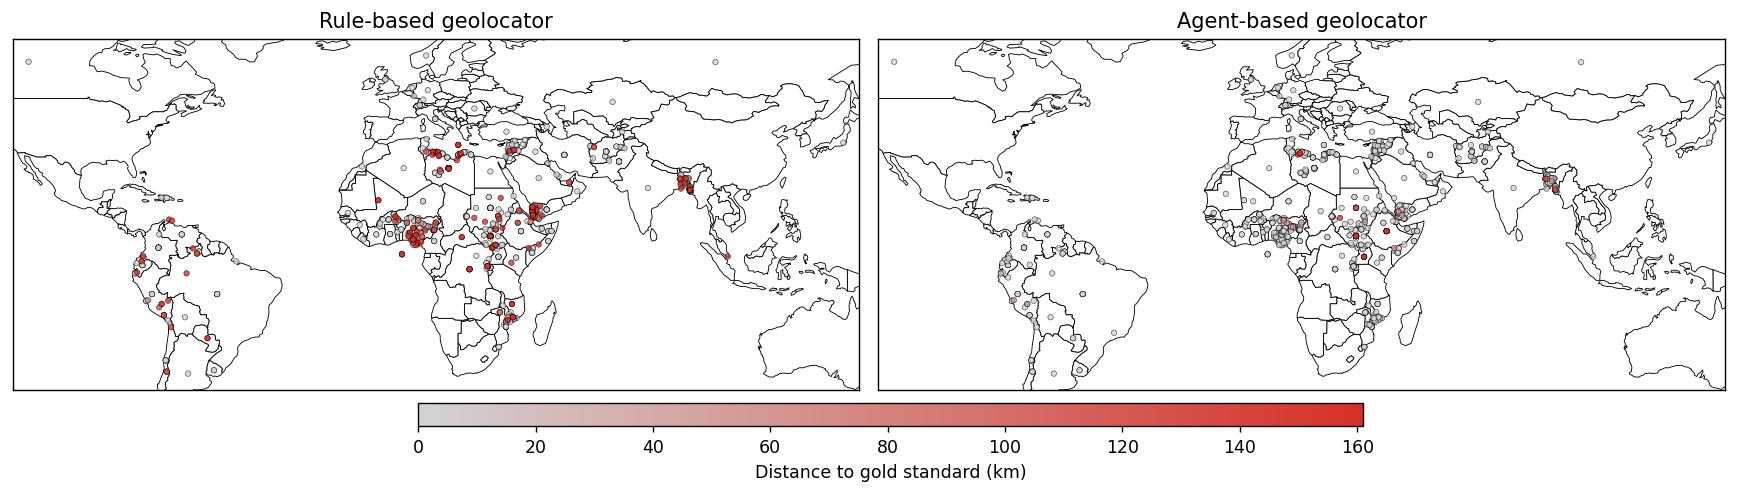

In [214]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

def matches_to_gdf(matches):
    rows = []
    for k in matches.keys():
        loc_map = matches[k][0]
        for l1, l2 in loc_map.items():
            dist_km = l1.distance(l2)
            rows.append({
                "geonameid": l1.geonameid,
                "name": l1.name,
                "country_code": l1.country_code,
                "distance_km": dist_km,
                "geometry": Point(l1.longitude, l1.latitude),
            })
    return gpd.GeoDataFrame(rows, crs="EPSG:4326")

# Build GDFs for rule-based and agent-based systems
gdf_rule = matches_to_gdf(rule_matches)
gdf_agent = matches_to_gdf(agent_matches)


min_lon = gdf_rule.geometry.x.min()
max_lon = gdf_rule.geometry.x.max()
min_lat = gdf_rule.geometry.y.min()
max_lat = gdf_rule.geometry.y.max()

margin = 5.0   # or 0.5, 2, 5 etc.
lon_min = min_lon - margin
lon_max = max_lon + margin
lat_min = min_lat - margin
lat_max = max_lat + margin

# Sort so that larger errors are plotted last (on top)
gdf_rule = gdf_rule.sort_values("distance_km")
gdf_agent = gdf_agent.sort_values("distance_km")

# Shared colormap: light grey -> coolwarm red
cmap_custom = LinearSegmentedColormap.from_list(
    "grey_to_red",
    ["#D3D3D3", "#d73027"]
)

# Shared normalization (color scale)
vmin = 0
vmax = 161  # or max(gdf_rule["distance_km"].max(), gdf_agent["distance_km"].max(), 166)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=125)

# Left: rule-based
ax = axes[0]
world.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)
gdf_rule.plot(
    ax=ax,
    column="distance_km",
    cmap=cmap_custom,
    norm=norm,
    markersize=10,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    legend=False,     # important: we'll add ONE shared colorbar
)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_title("Rule-based geolocator", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

# Right: agent-based
ax = axes[1]
world.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)
gdf_agent.plot(
    ax=ax,
    column="distance_km",
    cmap=cmap_custom,
    norm=norm,
    markersize=10,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    legend=False,
)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_title("Agent-based geolocator", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

# FIRST: Reserve space at the bottom so colorbar doesn't overlap
fig.subplots_adjust(bottom=-0.02)

# THEN: Create colorbar under both maps
sm = ScalarMappable(norm=norm, cmap=cmap_custom)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    pad=0.02,
    fraction=0.03,
    aspect=40,
    label="Distance to gold standard (km)"
)

plt.tight_layout()
plt.savefig("plots/map_white.png", bbox_inches='tight')
plt.show()